In [16]:
# =============================================================================
# GNN Configuration
# =============================================================================
gnn_type = 'gat'
save_to_folder = 'saved_models_GAT'

# =============================================================================
# Training & Cross-Validation
# =============================================================================
learning_rates = [0.0001]
max_norm_clipping = [5.0]

epochs_model_selection = 3000
epochs_train = 6000

minibatches = True
batch_size = 256
num_neighbors = [15, 10, 10]

patience_selection = 200
patience_training = 150

print_every = 10
save_every = 50

# =============================================================================
# Class Imbalance
# =============================================================================
downsample = True

# =============================================================================
# Temporal Train / Validation / Test Split
# =============================================================================
date_time_1 = '2022-09-07 14:55:00'
date_time_2 = '2022-09-08 09:44:00'
date_time_3 = '2022-09-09 03:16:00'

### Setup

In [17]:
import sys
sys.path.append('..')

In [18]:
from data_preparation import DataPreparation
from loader.dataset_factory import DatasetFactory
from model.gagnn import GAGNN
from model.loss import GAGNNLoss
from sklearn.metrics import f1_score
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from utils import Evaluator
import itertools
import json
import numpy as np
import os
import pandas as pd
import torch

In [19]:
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
set_seed(42)
torch.set_float32_matmul_precision('medium')

import IBM AMLSim

In [20]:
from loader.dataset_factory import DatasetFactory

# Inizializza il loader specificando il nome canonico del dataset
loader = DatasetFactory.get_loader(
    "ibm_amlsim", 
    engine="pyarrow", 
    dtype_backend="pyarrow", 
    nrows=None
)
# pyarrow is faster and uses less memory, it takes NumPy place

# Carica i dati in memoria (file delle transazioni e, se presente, degli account)
loader.load()

# Stampa un riepilogo conciso del dataset caricato per verificare che sia tutto ok
loader.summary()

Loading IBM AMLSim transactions from: c:\Users\marti\OneDrive\Desktop\Tesi v2\Code\Multiclass\..\loader\..\data\ibm_amlsim\HI-Small_Trans.csv
  Loaded 5,078,345 rows.
Loading IBM AMLSim accounts from: c:\Users\marti\OneDrive\Desktop\Tesi v2\Code\Multiclass\..\loader\..\data\ibm_amlsim\HI-Small_accounts.csv
  Loaded 518,581 account records.
  Dataset : IBMAMLSimLoader
  Rows    : 5,078,345
  Columns : 11
  Fraud   : 5,177  (0.1019 %)



In [21]:
loader.print_features()


Column               Type         Description
--------------------------------------------------------------------------------
Timestamp            string[pyarrow] Date and time of the transaction
From Bank            int64[pyarrow] Numeric identifier of the originating bank  (e.g. [1, 10, 12, 3208, 3209])
Account              string[pyarrow] Hexadecimal ID of the sender account (node)
To Bank              int64[pyarrow] Numeric identifier of the receiving bank  (e.g. [1, 10, 12, 2439, 3209])
Account.1            string[pyarrow] Hexadecimal ID of the receiver account (node)
Amount Received      double[pyarrow] Transaction amount in the receiving currency
Receiving Currency   string[pyarrow] Currency received by the destination account  (e.g. ['US Dollar', 'Bitcoin', 'Euro', 'Australian Dollar', 'Yuan', 'Rupee'])
Amount Paid          double[pyarrow] Transaction amount in the paying currency
Payment Currency     string[pyarrow] Currency used by the sender  (e.g. ['US Dollar', 'Bitcoin',

Data preparation

In [22]:
from data_preparation import DataPreparation
import pandas as pd

# Otteniamo il dataframe raw delle transazioni dal nostro loader
transactions_df = loader.get_transactions()

# Parse multiclass patterns
data_prep = DataPreparation(scaler_type='robust')
transactions_df = data_prep.parse_patterns_file(transactions_df, '../data/ibm_amlsim/HI-Small_Patterns.txt')

# Calcoliamo la maschera di training per evitare data leakage nello scaler
ts_raw = pd.to_datetime(transactions_df['Timestamp'])
thresh_patience = pd.to_datetime(date_time_1)
train_mask_raw = ts_raw < thresh_patience

# Inizializziamo la classe scegliendo il robust scaler
data_prep = DataPreparation(scaler_type='robust')

# 1. Calcoliamo le feature standardizzate per le transazioni (gli archi E)
edges_features_df = data_prep.fit_transform_edges(transactions_df, train_mask=train_mask_raw)

# 2. Aggreghiamo le transazioni per ricavare l'embedding iniziale dei nodi (V)
nodes_features_df = data_prep.get_node_features(edges_features_df, train_mask=train_mask_raw)

print(f"Dimensione feature archi: {edges_features_df.shape}")
print(f"Dimensione feature nodi: {nodes_features_df.shape}")

# Stampa bilanciamento classi (Nodi e Archi)
print("\n--- Bilanciamento Dataset ---")
num_fraud_nodes = (nodes_features_df["Is Laundering"] > 0).sum()
num_legit_nodes = len(nodes_features_df) - num_fraud_nodes
print(f"Nodi fraudolenti: {num_fraud_nodes} ({num_fraud_nodes/len(nodes_features_df)*100:.2f}%)")
print(f"Nodi leciti:      {num_legit_nodes} ({num_legit_nodes/len(nodes_features_df)*100:.2f}%)")

num_fraud_edges = (edges_features_df["Is Laundering"] > 0).sum()
num_legit_edges = len(edges_features_df) - num_fraud_edges
print(f"Archi fraudolenti: {num_fraud_edges} ({num_fraud_edges/len(edges_features_df)*100:.2f}%)")
print(f"Archi leciti:      {num_legit_edges} ({num_legit_edges/len(edges_features_df)*100:.2f}%)")

print("\n--- Features degli archi ---")
print(list(edges_features_df.columns))

print("\n--- Features dei nodi ---")
print(list(nodes_features_df.columns))


Parsing patterns from ../data/ibm_amlsim/HI-Small_Patterns.txt...
Dropped 1968 illicit transactions lacking a specific multiclass pattern label.
Matched 3209 illicit transactions from patterns file.
Extracting time features (Unix time, Cyclic Hour, Day of Week, Week)...
Applying edge transformation (Amounts: robust, Time: standard)...
Aggregating node features and extracting ground truth labels...
Dimensione feature archi: (5076377, 54)
Dimensione feature nodi: (515039, 50)

--- Bilanciamento Dataset ---
Nodi fraudolenti: 3170 (0.62%)
Nodi leciti:      511869 (99.38%)
Archi fraudolenti: 3209 (0.06%)
Archi leciti:      5073168 (99.94%)

--- Features degli archi ---
['Amount Received', 'Amount Paid', 'Receiving Currency_Australian Dollar', 'Receiving Currency_Bitcoin', 'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar', 'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso', 'Receiving Currency_Ruble', 'Receiving Currency_Rupee', 'Receiving Currency_Saudi Riyal'

In [23]:
import torch
import numpy as np
import pandas as pd

print("--- Downsampling Strategy (1:1 Ratio) ---")
# 1. Identify Fraudulent and Legitimate Nodes
# A node is fraudulent if it was involved in at least one ML transaction
fraud_nodes = nodes_features_df[nodes_features_df["Is Laundering"] > 0].index
legit_nodes = nodes_features_df[nodes_features_df["Is Laundering"] == 0].index

print(f"Total Fraudulent Nodes: {len(fraud_nodes)}")
print(f"Total Legitimate Nodes (before sampling): {len(legit_nodes)}")

# 2. Sample Legitimate Nodes (1:1 ratio)
sampled_legit_nodes = pd.Series(legit_nodes).sample(n=len(fraud_nodes), random_state=42).values

# 3. Combine to form the final set of sampled users
sampled_users = set(fraud_nodes).union(set(sampled_legit_nodes))
print(f"Total Nodes after downsampling: {len(sampled_users)}")

# 4. Filter nodes_features_df and edges_features_df efficiently
nodes_features_df = nodes_features_df.loc[list(sampled_users)]

# Filter transactions: keep only those where BOTH sender and receiver are in sampled_users
edges_features_df = edges_features_df[
    edges_features_df['Account'].isin(sampled_users) & 
    edges_features_df['Account.1'].isin(sampled_users)
]

print(f"Total Edges after downsampling: {len(edges_features_df)}")

# 5. Map string Account IDs to integers (0 to N-1) for PyTorch Geometric
unique_nodes = nodes_features_df.index.unique()
node_mapping = pd.Series(index=unique_nodes, data=np.arange(len(unique_nodes)))

# 6. Extract edge_index
src = edges_features_df['Account'].map(node_mapping).values
dst = edges_features_df['Account.1'].map(node_mapping).values
edge_index = torch.tensor(np.vstack((src, dst)), dtype=torch.long)

# 7. Extract edge features and transaction labels
edge_features_cols = [c for c in edges_features_df.columns if c not in ['Account', 'Account.1', 'Is Laundering', 'Laundering_Type', 'Timestamp']]
edge_attr = torch.tensor(edges_features_df[edge_features_cols].values, dtype=torch.float)
y_trans = torch.tensor(edges_features_df['Laundering_Type'].values, dtype=torch.long).unsqueeze(1)

# 8. Extract node features and node labels
node_features_cols = [c for c in nodes_features_df.columns if c != 'Is Laundering']
x = torch.tensor(nodes_features_df[node_features_cols].values, dtype=torch.float)

y_node = torch.tensor(nodes_features_df['Is Laundering'].values, dtype=torch.float)

print(f"Node features shape: {x.shape}")
print(f"Edge index shape: {edge_index.shape}")
print(f"Edge features shape: {edge_attr.shape}")









--- Downsampling Strategy (1:1 Ratio) ---
Total Fraudulent Nodes: 3170
Total Legitimate Nodes (before sampling): 511869
Total Nodes after downsampling: 6340
Total Edges after downsampling: 17029
Node features shape: torch.Size([6340, 49])
Edge index shape: torch.Size([2, 17029])
Edge features shape: torch.Size([17029, 49])


In [ ]:
import pandas as pd
from torch_geometric.data import Data

# Convert Timestamp column to datetime (use downsampled edges_features_df)
ts = pd.to_datetime(edges_features_df['Timestamp'])

date_time_4 = "2022/09/10 23:21"

# Thresholds for splits
thresh_patience = pd.to_datetime(date_time_1)
thresh_val = pd.to_datetime(date_time_2)
thresh_test = pd.to_datetime(date_time_3)
thres_discard = pd.to_datetime(date_time_4)

# Create edge masks based on chronological splits
train_edge_mask = torch.tensor((ts < thresh_patience).values, dtype=torch.bool)
patience_edge_mask = torch.tensor(((ts >= thresh_patience) & (ts < thresh_val)).values, dtype=torch.bool)
val_edge_mask = torch.tensor(((ts >= thresh_val) & (ts < thresh_test)).values, dtype=torch.bool)
test_edge_mask = torch.tensor(((ts >= thresh_test)&(ts<=date_time_4)).values, dtype=torch.bool)

print(f"Train edges: {train_edge_mask.sum().item()} ({train_edge_mask.sum().item()/len(ts)*100:.1f}%)")
print(f"Patience edges: {patience_edge_mask.sum().item()} ({patience_edge_mask.sum().item()/len(ts)*100:.1f}%)\nVal edges: {val_edge_mask.sum().item()} ({val_edge_mask.sum().item()/len(ts)*100:.1f}%)")
print(f"Test edges: {test_edge_mask.sum().item()} ({test_edge_mask.sum().item()/len(ts)*100:.1f}%)")

# Create node masks for NeighborLoader input_nodes
# A node is in the training set if it is connected to at least one training edge
train_nodes_idx = edge_index[:, train_edge_mask].flatten().unique()
train_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
train_node_mask[train_nodes_idx] = True

patience_nodes_idx = edge_index[:, patience_edge_mask].flatten().unique()
patience_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
patience_node_mask[patience_nodes_idx] = True

val_nodes_idx = edge_index[:, val_edge_mask].flatten().unique()
val_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
val_node_mask[val_nodes_idx] = True

test_nodes_idx = edge_index[:, test_edge_mask].flatten().unique()
test_node_mask = torch.zeros(x.shape[0], dtype=torch.bool)
test_node_mask[test_nodes_idx] = True

# Node mask: Using all True, as GAGNN expects a probability label for all nodes
node_mask = torch.ones(x.shape[0], dtype=torch.bool)

# Build PyG Data object
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y_trans=y_trans, y_node=y_node)
data.node_mask = node_mask
data.edge_train_mask = train_edge_mask
data.edge_patience_mask = patience_edge_mask
data.edge_val_mask = val_edge_mask
data.edge_test_mask = test_edge_mask
data.train_node_mask = train_node_mask
data.patience_node_mask = patience_node_mask
data.val_node_mask = val_node_mask
data.test_node_mask = test_node_mask

Train edges: 12607 (74.0%)
Patience edges: 799 (4.7%)
Val edges: 783 (4.6%)
Test edges: 2840 (16.7%)


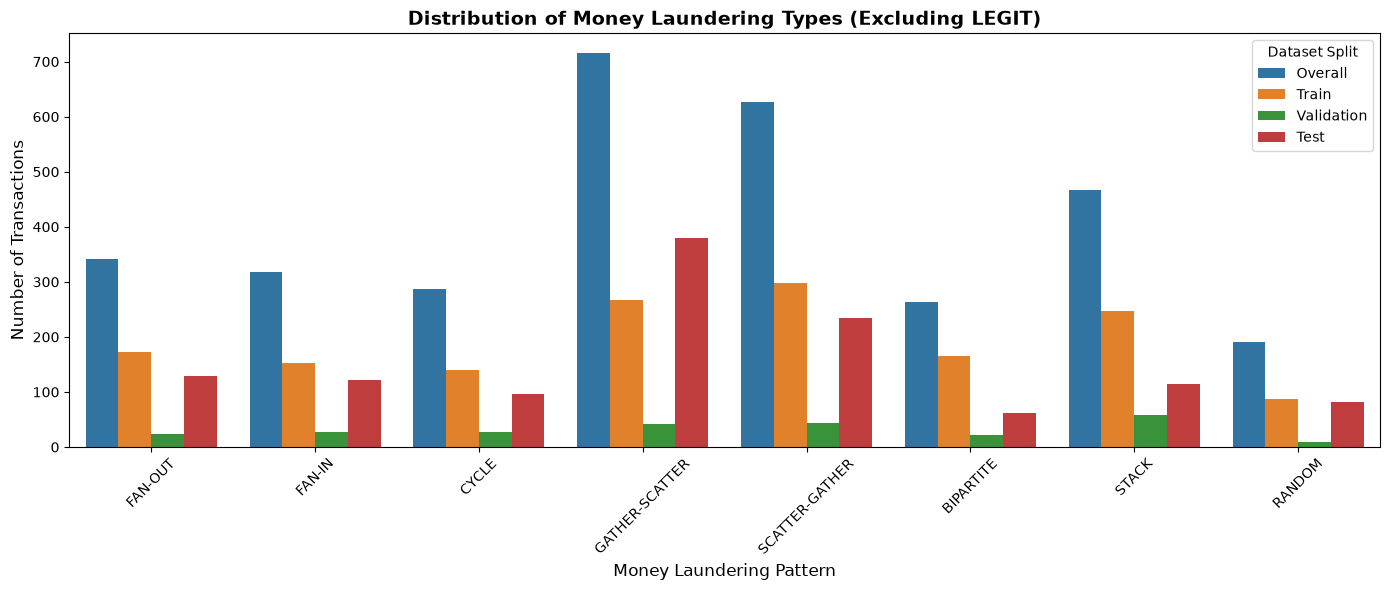

In [25]:
from utils import Evaluator

# Plot the distribution of money laundering types across the splits
Evaluator.plot_multiclass_distribution(
    y_trans=data.y_trans,
    train_edge_mask=data.edge_train_mask,
    val_edge_mask=data.edge_val_mask,
    test_edge_mask=data.edge_test_mask
)

### Pre Model Selection (c1, c2, c3)

In [ ]:
# Pre-Model Selection Grid (fixing architecture, varying c1,c2,c3)
pre_hidden_dims = [128]
pre_out_dims = [128]
pre_nn_t_hidden_dims = [128]
pre_max_norm_clipping = [5.0]
pre_heads_list = [5]
pre_num_layers_list = [2]
pre_betas = [0.44]
pre_mlp_hidden_dims = [128]
pre_learning_rates = [0.0001]

# Vary c1, c2, c3
pre_c1_list = [0.75]
pre_c2_list = [0.75]
pre_c3_list = [0.9]

import os
import json
import itertools
from model.gagnn import GAGNN
from model.loss import GAGNNLoss
from torch_geometric.loader import NeighborLoader
from sklearn.metrics import f1_score
import torch

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

keys = ['max_norm', 'hidden_dim', 'out_dim', 'heads', 'num_layers',
        'beta', 'mlp_hidden_dim', 'nn_t_hidden_dim', 'lr',
        'c1', 'c2', 'c3']
combinations = list(itertools.product(
    pre_max_norm_clipping, pre_hidden_dims, pre_out_dims, pre_heads_list, pre_num_layers_list,
    pre_betas, pre_mlp_hidden_dims, pre_nn_t_hidden_dims, pre_learning_rates,
    pre_c1_list, pre_c2_list, pre_c3_list
))


print(f"Total PRE-MODEL SELECTION hyperparameter combinations: {len(combinations)}\n")
os.makedirs(save_to_folder, exist_ok=True)
with open(f"{save_to_folder}/configurations_pre_selection.txt", "w") as _f:
    _f.write(f"Total configurations tested: {len(combinations)}\n\n")
    _f.write("Hyperparameter grids:\n")
    _f.write(f"pre_max_norm_clipping: {pre_max_norm_clipping}\n")
    _f.write(f"pre_hidden_dims: {pre_hidden_dims}\n")
    _f.write(f"pre_out_dims: {pre_out_dims}\n")
    _f.write(f"pre_heads_list: {pre_heads_list}\n")
    _f.write(f"pre_num_layers_list: {pre_num_layers_list}\n")
    _f.write(f"pre_betas: {pre_betas}\n")
    _f.write(f"pre_mlp_hidden_dims: {pre_mlp_hidden_dims}\n")
    _f.write(f"pre_nn_t_hidden_dims: {pre_nn_t_hidden_dims}\n")
    _f.write(f"pre_learning_rates: {pre_learning_rates}\n")
    _f.write(f"pre_c1_list: {pre_c1_list}\n")
    _f.write(f"pre_c2_list: {pre_c2_list}\n")
    _f.write(f"pre_c3_list: {pre_c3_list}\n")

best_val_f1 = -1.0
best_pre_params = None



os.makedirs(save_to_folder, exist_ok=True)


print("Computing class weights for the training set...")
y_train_flat = y_trans[train_edge_mask].view(-1).cpu().numpy()
classes = np.unique(y_train_flat)
class_weights_np = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_flat)
class_weights = torch.ones(9, dtype=torch.float)
for i, c in enumerate(classes):
    class_weights[int(c)] = class_weights_np[i]
class_weights = class_weights.to(device)

for idx, combo in enumerate(combinations):
    params = dict(zip(keys, combo))

    current_num_neighbors = num_neighbors.copy()
    while len(current_num_neighbors) < params['num_layers']:
        current_num_neighbors.append(current_num_neighbors[-1] if current_num_neighbors else 10)
    current_num_neighbors = current_num_neighbors[:params['num_layers']]
    
    if minibatches:
        train_loader = NeighborLoader(
            data, num_neighbors=current_num_neighbors, batch_size=batch_size,
            input_nodes=data.train_node_mask, shuffle=True
        )
        patience_loader = NeighborLoader(
            data, num_neighbors=[-1] * params['num_layers'], batch_size=batch_size,
            input_nodes=data.patience_node_mask, shuffle=False
        )
        val_loader = NeighborLoader(
            data, num_neighbors=[-1] * params['num_layers'], batch_size=batch_size,
            input_nodes=data.val_node_mask, shuffle=False
        )
    else:
        d_dev = data.to(device)
        train_loader = [d_dev]
        patience_loader = [d_dev]
        val_loader = [d_dev]
    print(f"--- Pre-Selection Experiment {idx+1}/{len(combinations)} ---")
    print(params)
    
    model = GAGNN(
        node_in_dim=x.shape[1],
        edge_feat_dim=edge_attr.shape[1],
        hidden_dim=params['hidden_dim'],
        out_dim=params['out_dim'],
        heads=params['heads'],
        beta=params['beta'],
        mlp_hidden_dim=params['mlp_hidden_dim'],
        nn_t_hidden_dim=params['nn_t_hidden_dim'],
        minibatches=minibatches, num_classes=9,
        gnn_type=gnn_type,
        num_layers=params['num_layers']
    ).to(device)
    
    criterion = GAGNNLoss(c1=params['c1'], c2=params['c2'], c3=params['c3'], laundry_weight=class_weights, task='multiclass')
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    scaler = torch.amp.GradScaler('cuda', enabled=False)
    
    epochs_no_improve = 0
    best_model_val_loss = float('inf')
    best_epoch_patience_loss = float('inf')
    best_model_val_f1 = -1.0
    
    for epoch in range(epochs_model_selection):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                p_node, p_trans, p_group, y_group = model(
                    batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                    y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=batch.edge_train_mask
                )
            
            if p_group.numel() > 0:
                loss, _, _, _ = criterion(
                    p_node, batch.y_node.view(-1, 1),
                    p_trans, batch.y_trans,
                    p_group, y_group,
                    node_mask=batch.node_mask,
                    trans_mask=batch.edge_train_mask
                )
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=params['max_norm'])
                scaler.step(optimizer)
                scaler.update()
                epoch_loss += loss.item()
                n_batches += 1
                
        train_loss = epoch_loss / max(n_batches, 1)
        
        model.eval()
        patience_loss_epoch = 0.0
        n_patience_batches = 0
        with torch.no_grad():
            for batch in patience_loader:
                batch = batch.to(device)
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    p_node, p_trans, p_group, y_group = model(
                        batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                        y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=batch.edge_patience_mask
                    )
                if p_group.numel() > 0:
                    loss, _, _, _ = criterion(
                        p_node, batch.y_node.view(-1, 1),
                        p_trans, batch.y_trans,
                        p_group, y_group,
                        node_mask=batch.node_mask,
                        trans_mask=batch.edge_patience_mask
                    )
                    patience_loss_epoch += loss.item()
                    n_patience_batches += 1
        patience_loss = patience_loss_epoch / max(n_patience_batches, 1)

        if patience_loss < best_epoch_patience_loss:
            best_epoch_patience_loss = patience_loss
            epochs_no_improve = 0

            val_loss_epoch = 0.0
            n_val_batches = 0
            all_y_true = []
            all_y_pred = []
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                        p_node, p_trans, p_group, y_group = model(
                            batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                            y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=batch.edge_val_mask
                        )
                    if p_group.numel() > 0:
                        loss, _, _, _ = criterion(
                            p_node, batch.y_node.view(-1, 1),
                            p_trans, batch.y_trans,
                            p_group, y_group,
                            node_mask=batch.node_mask,
                            trans_mask=batch.edge_val_mask
                        )
                        val_loss_epoch += loss.item()
                        n_val_batches += 1
                    
                        mask = batch.edge_val_mask
                        if p_trans.shape[0] == mask.shape[0]:
                            p_trans_val = p_trans[mask]
                            y_trans_val = batch.y_trans[mask]
                        else:
                            p_trans_val = p_trans
                            y_trans_val = batch.y_trans
                        
                        if len(p_trans_val.shape) > 1 and p_trans_val.shape[1] > 1:
                            preds = torch.argmax(p_trans_val, dim=1).cpu().numpy()
                        else:
                            if p_trans_val.min() >= 0 and p_trans_val.max() <= 1:
                                preds = (p_trans_val > 0.5).long().cpu().numpy()
                            else:
                                preds = (p_trans_val > 0).long().cpu().numpy()
                    
                        trues = y_trans_val.cpu().numpy()
                        all_y_pred.extend(preds.flatten())
                        all_y_true.extend(trues.flatten())


            val_loss = val_loss_epoch / max(n_val_batches, 1)
            val_f1 = f1_score(all_y_true, all_y_pred, average='macro') if len(all_y_true) > 0 else 0.0
            best_model_val_loss = val_loss

            best_model_val_f1 = val_f1
            print(f"epoch {epoch+1:03d} | new best val f1 for this configuration: {best_model_val_f1:.4f}")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience_selection:
            print(f"Patience triggered at epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
            break
            
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")   
            
    print(f"Best Val F1 for this config: {best_model_val_f1:.4f}")
    if best_model_val_f1 > best_val_f1:
        best_val_f1 = best_model_val_f1
        best_pre_params = params
        model.save(f"{save_to_folder}/gagnn_best_pre_selection.pt")
        print(">>> New Best Pre-Selection Parameters! Model saved.")

print("\n=========================================")
print(f"Overall Best Val F1 (Pre-Selection): {best_val_f1:.4f}")
print(f"Best Pre-Selection Parameters: {best_pre_params}")
print("=========================================")
with open(f"{save_to_folder}/best_pre_params.json", "w") as f:
    json.dump(best_pre_params, f, indent=4)

# Update the main grid search c1, c2, c3 lists to the best ones found
c1_list = [best_pre_params['c1']]
c2_list = [best_pre_params['c2']]
c3_list = [best_pre_params['c3']]
print(f"Setting c1_list={c1_list}, c2_list={c2_list}, c3_list={c3_list} for Architecture Model Selection.")


Total PRE-MODEL SELECTION hyperparameter combinations: 4

Computing class weights for the training set...
--- Pre-Selection Experiment 1/4 ---
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 128, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 128, 'nn_t_hidden_dim': 128, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.6, 'c3': 0.9}


c:\Users\marti\OneDrive\Desktop\Tesi v2\Code\Multiclass\..\model\loss.py:36: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:255.)
  pos_weight = torch.tensor([self.laundry_weight], device=p_node.device) if self.task == 'binary' or not isinstance(self.laundry_weight, torch.Tensor) else None


epoch 001 | new best val f1 for this configuration: 0.1058
epoch 003 | new best val f1 for this configuration: 0.0564
epoch 005 | new best val f1 for this configuration: 0.1001
epoch 006 | new best val f1 for this configuration: 0.0953
epoch 007 | new best val f1 for this configuration: 0.1077
epoch 009 | new best val f1 for this configuration: 0.1384
epoch 010 | new best val f1 for this configuration: 0.1158
Epoch 010 | Train Loss: 4.2613 | Val Loss: 7.6053 | Val F1: 0.1158
epoch 012 | new best val f1 for this configuration: 0.1121
epoch 014 | new best val f1 for this configuration: 0.1153
epoch 017 | new best val f1 for this configuration: 0.0965
Epoch 020 | Train Loss: 2.6786 | Val Loss: 7.1357 | Val F1: 0.0965
epoch 022 | new best val f1 for this configuration: 0.1342
epoch 024 | new best val f1 for this configuration: 0.1288
epoch 028 | new best val f1 for this configuration: 0.1344
Epoch 030 | Train Loss: 2.1081 | Val Loss: 3.6309 | Val F1: 0.1344
Epoch 040 | Train Loss: 1.8099 |

### Model selection

In [ ]:
hidden_dims = [128] #64 paper
out_dims = [128, 256]
num_layers_list = [2] # 2 paper
betas = [0.44] #paper
mlp_hidden_dims = [128, 256]
nn_t_hidden_dims = [256] #128 paper
heads_list = [5]

c1_list = [best_pre_params['c1']]
c2_list = [best_pre_params['c2']]
c3_list = [best_pre_params['c3']]

Computing class weights for the training set...
Class weights: tensor([ 0.1264,  8.1441,  9.2156, 10.0056,  5.2464,  4.7006,  8.4384,  5.6712,
        16.1009], device='cuda:0')
Total hyperparameter combinations: 8

--- Experiment 1/8 ---
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 128, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 128, 'nn_t_hidden_dim': 128, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9}
Best Val Loss for this config: 22.2433
>>> New Best Parameters! Model saved.
Best Val Loss for this config: 16.2704
>>> New Best Parameters! Model saved.
Best Val Loss for this config: 12.5535
>>> New Best Parameters! Model saved.
Best Val Loss for this config: 12.5535
No improvement over best parameters. Current: 12.5535 | Best: 12.5535
Best Val Loss for this config: 10.7555
>>> New Best Parameters! Model saved.
Best Val Loss for this config: 9.8273
>>> New Best Parameters! Model saved.
Best Val Loss for this config: 9.8273
No improvement over best parameters. C

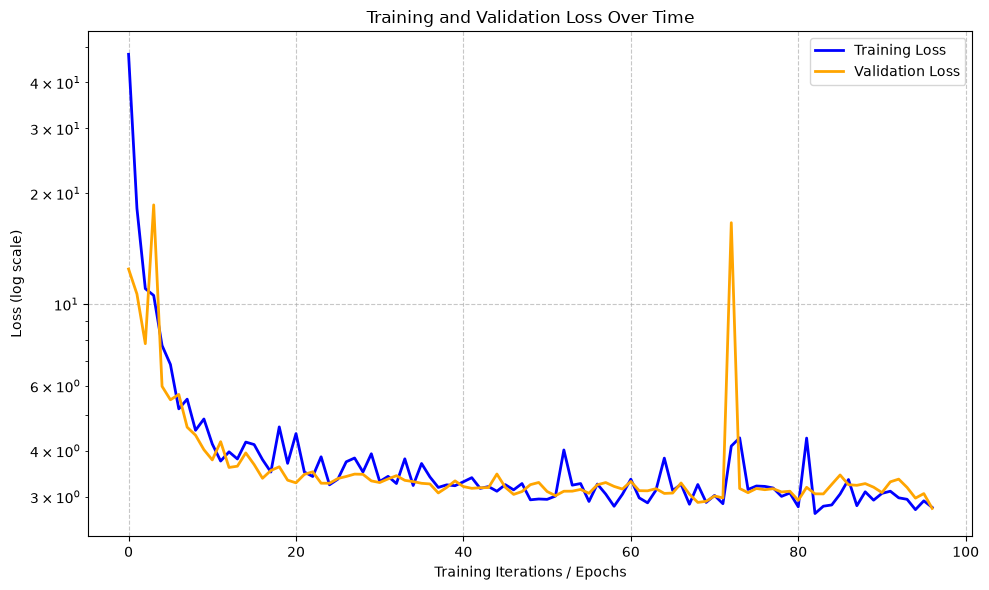

--- Experiment 2/8 ---
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 128, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 128, 'nn_t_hidden_dim': 256, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9}
Best Val Loss for this config: 54.8370
No improvement over best parameters. Current: 54.8370 | Best: 3.3007
Best Val Loss for this config: 22.2320
No improvement over best parameters. Current: 22.2320 | Best: 3.3007
Best Val Loss for this config: 25.6600
No improvement over best parameters. Current: 25.6600 | Best: 3.3007
Best Val Loss for this config: 17.9725
No improvement over best parameters. Current: 17.9725 | Best: 3.3007
Best Val Loss for this config: 16.4027
No improvement over best parameters. Current: 16.4027 | Best: 3.3007
Best Val Loss for this config: 16.4027
No improvement over best parameters. Current: 16.4027 | Best: 3.3007
Best Val Loss for this config: 16.4475
No improvement over best parameters. Current: 16.4475 | Best: 3.3007
Best Val Loss for this config

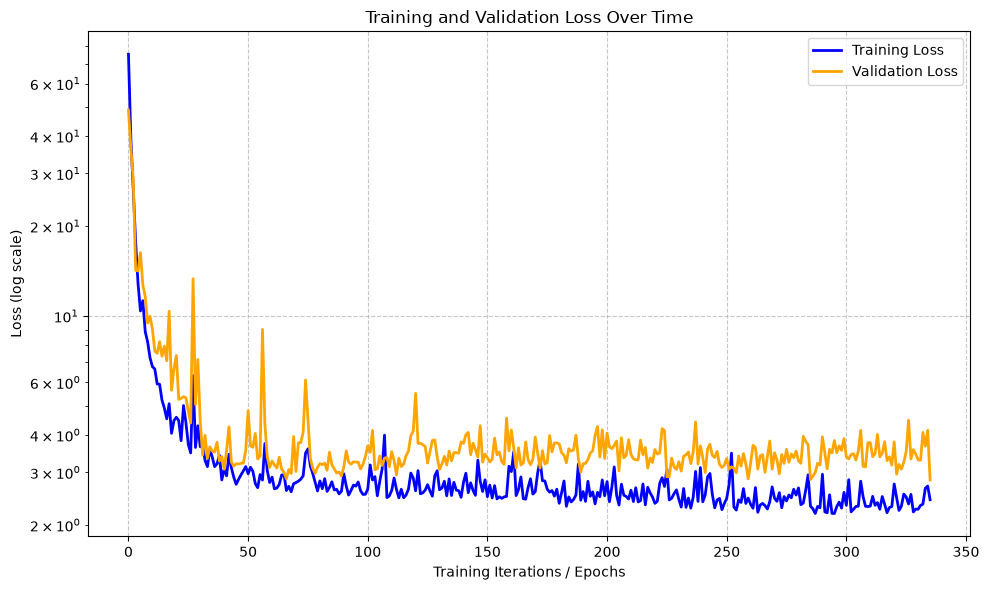

--- Experiment 3/8 ---
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 128, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 256, 'nn_t_hidden_dim': 128, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9}
Best Val Loss for this config: 50.4310
No improvement over best parameters. Current: 50.4310 | Best: 3.2200
Best Val Loss for this config: 28.9627
No improvement over best parameters. Current: 28.9627 | Best: 3.2200
Best Val Loss for this config: 23.2086
No improvement over best parameters. Current: 23.2086 | Best: 3.2200
Best Val Loss for this config: 15.7359
No improvement over best parameters. Current: 15.7359 | Best: 3.2200
Best Val Loss for this config: 15.7359
No improvement over best parameters. Current: 15.7359 | Best: 3.2200
Best Val Loss for this config: 13.3406
No improvement over best parameters. Current: 13.3406 | Best: 3.2200
Best Val Loss for this config: 10.4054
No improvement over best parameters. Current: 10.4054 | Best: 3.2200
Best Val Loss for this config

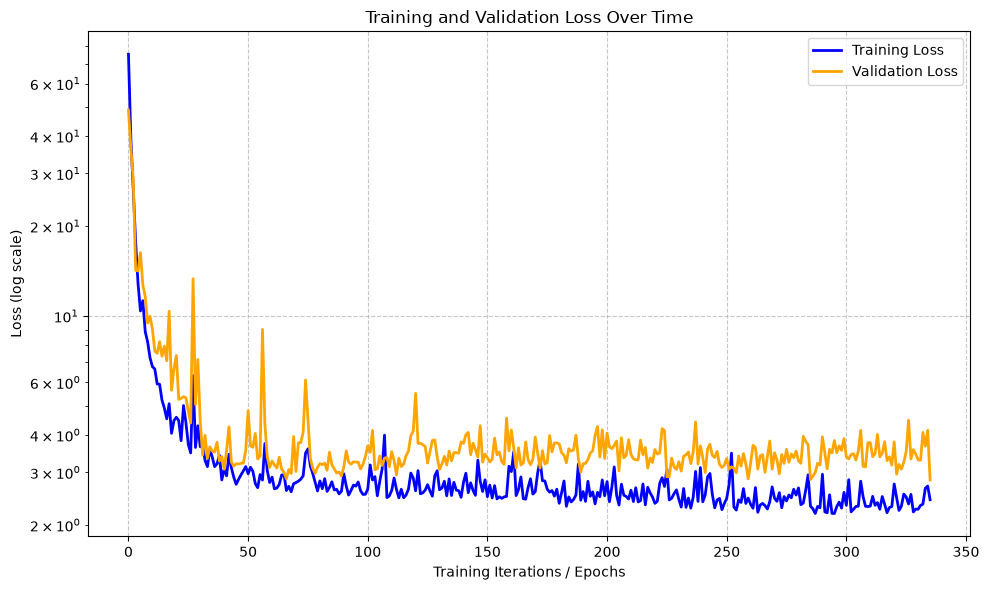

--- Experiment 4/8 ---
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 128, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 256, 'nn_t_hidden_dim': 256, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9}
Best Val Loss for this config: 37.9161
No improvement over best parameters. Current: 37.9161 | Best: 3.2200
Best Val Loss for this config: 30.0537
No improvement over best parameters. Current: 30.0537 | Best: 3.2200
Best Val Loss for this config: 23.8349
No improvement over best parameters. Current: 23.8349 | Best: 3.2200
Best Val Loss for this config: 17.5652
No improvement over best parameters. Current: 17.5652 | Best: 3.2200
Best Val Loss for this config: 13.7997
No improvement over best parameters. Current: 13.7997 | Best: 3.2200
Best Val Loss for this config: 13.7997
No improvement over best parameters. Current: 13.7997 | Best: 3.2200
Best Val Loss for this config: 12.5765
No improvement over best parameters. Current: 12.5765 | Best: 3.2200
Best Val Loss for this config

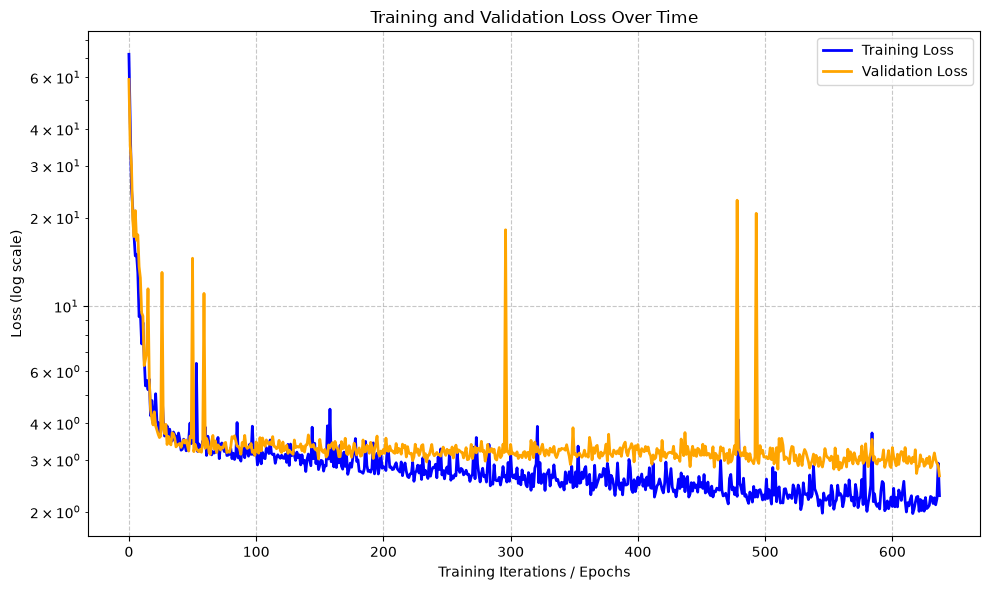

--- Experiment 5/8 ---
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 256, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 128, 'nn_t_hidden_dim': 128, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9}
Best Val Loss for this config: 29.1002
No improvement over best parameters. Current: 29.1002 | Best: 2.7393
Best Val Loss for this config: 29.1571
No improvement over best parameters. Current: 29.1571 | Best: 2.7393
Best Val Loss for this config: 24.0232
No improvement over best parameters. Current: 24.0232 | Best: 2.7393
Best Val Loss for this config: 14.9783
No improvement over best parameters. Current: 14.9783 | Best: 2.7393
Best Val Loss for this config: 14.9783
No improvement over best parameters. Current: 14.9783 | Best: 2.7393
Best Val Loss for this config: 13.9515
No improvement over best parameters. Current: 13.9515 | Best: 2.7393
Best Val Loss for this config: 10.3256
No improvement over best parameters. Current: 10.3256 | Best: 2.7393
Best Val Loss for this config

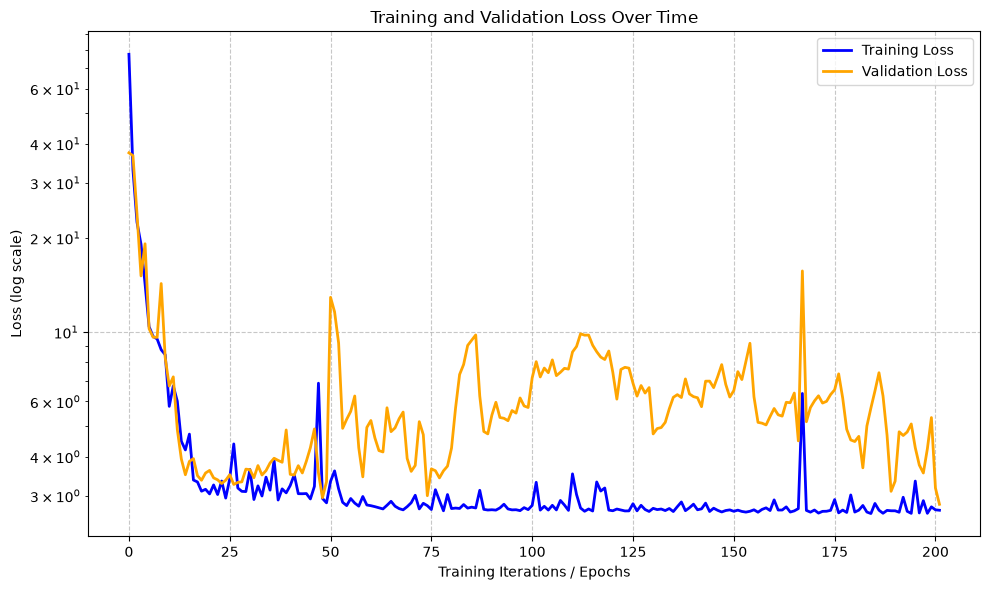

--- Experiment 6/8 ---
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 256, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 128, 'nn_t_hidden_dim': 256, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9}
Best Val Loss for this config: 30.0349
No improvement over best parameters. Current: 30.0349 | Best: 2.6867
Best Val Loss for this config: 24.1443
No improvement over best parameters. Current: 24.1443 | Best: 2.6867
Best Val Loss for this config: 16.7939
No improvement over best parameters. Current: 16.7939 | Best: 2.6867
Best Val Loss for this config: 16.7939
No improvement over best parameters. Current: 16.7939 | Best: 2.6867
Best Val Loss for this config: 11.1576
No improvement over best parameters. Current: 11.1576 | Best: 2.6867
Best Val Loss for this config: 11.1576
No improvement over best parameters. Current: 11.1576 | Best: 2.6867
Best Val Loss for this config: 11.1576
No improvement over best parameters. Current: 11.1576 | Best: 2.6867
Best Val Loss for this config

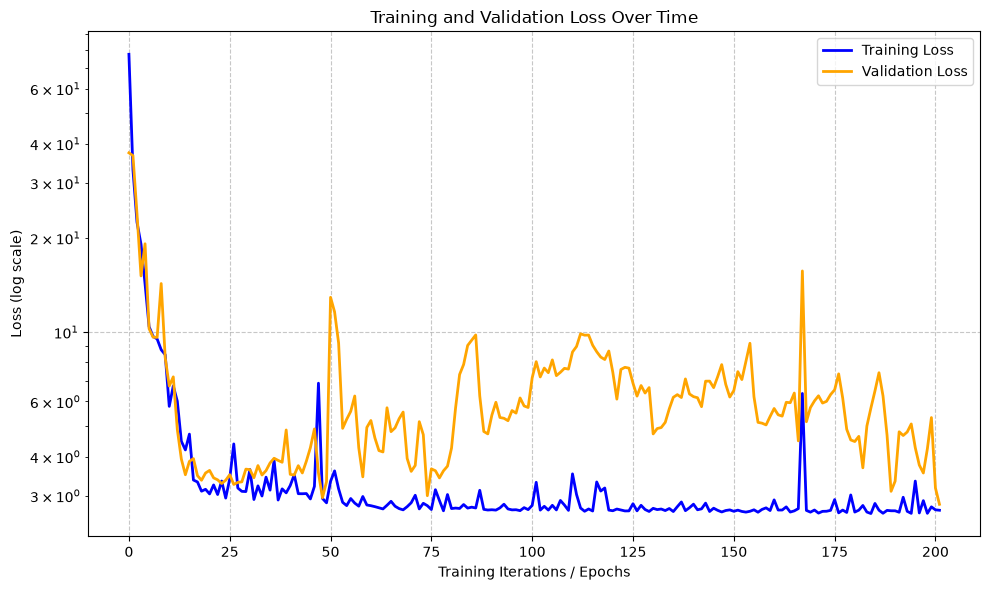

--- Experiment 7/8 ---
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 256, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 256, 'nn_t_hidden_dim': 128, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9}
Best Val Loss for this config: 22.7130
No improvement over best parameters. Current: 22.7130 | Best: 2.6867
Best Val Loss for this config: 23.3044
No improvement over best parameters. Current: 23.3044 | Best: 2.6867
Best Val Loss for this config: 16.8824
No improvement over best parameters. Current: 16.8824 | Best: 2.6867
Best Val Loss for this config: 16.8824
No improvement over best parameters. Current: 16.8824 | Best: 2.6867
Best Val Loss for this config: 16.8824
No improvement over best parameters. Current: 16.8824 | Best: 2.6867
Best Val Loss for this config: 13.3147
No improvement over best parameters. Current: 13.3147 | Best: 2.6867
Best Val Loss for this config: 13.3147
No improvement over best parameters. Current: 13.3147 | Best: 2.6867
Best Val Loss for this config

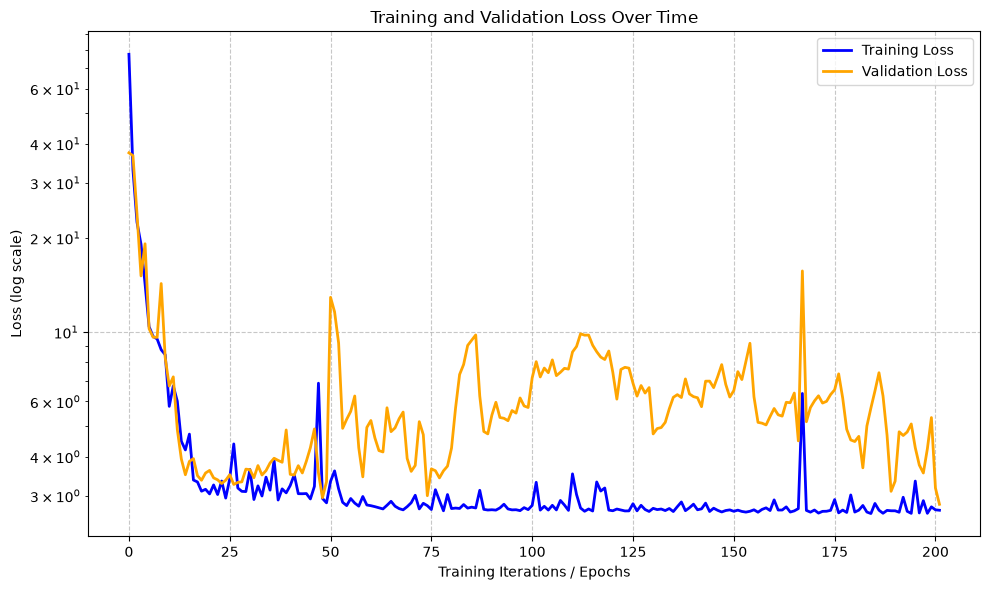

--- Experiment 8/8 ---
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 256, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 256, 'nn_t_hidden_dim': 256, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9}
Best Val Loss for this config: 35.2387
No improvement over best parameters. Current: 35.2387 | Best: 2.6867
Best Val Loss for this config: 23.6926
No improvement over best parameters. Current: 23.6926 | Best: 2.6867
Best Val Loss for this config: 24.4350
No improvement over best parameters. Current: 24.4350 | Best: 2.6867
Best Val Loss for this config: 17.5368
No improvement over best parameters. Current: 17.5368 | Best: 2.6867
Best Val Loss for this config: 17.8635
No improvement over best parameters. Current: 17.8635 | Best: 2.6867
Best Val Loss for this config: 16.8891
No improvement over best parameters. Current: 16.8891 | Best: 2.6867
Best Val Loss for this config: 16.8891
No improvement over best parameters. Current: 16.8891 | Best: 2.6867
Best Val Loss for this config

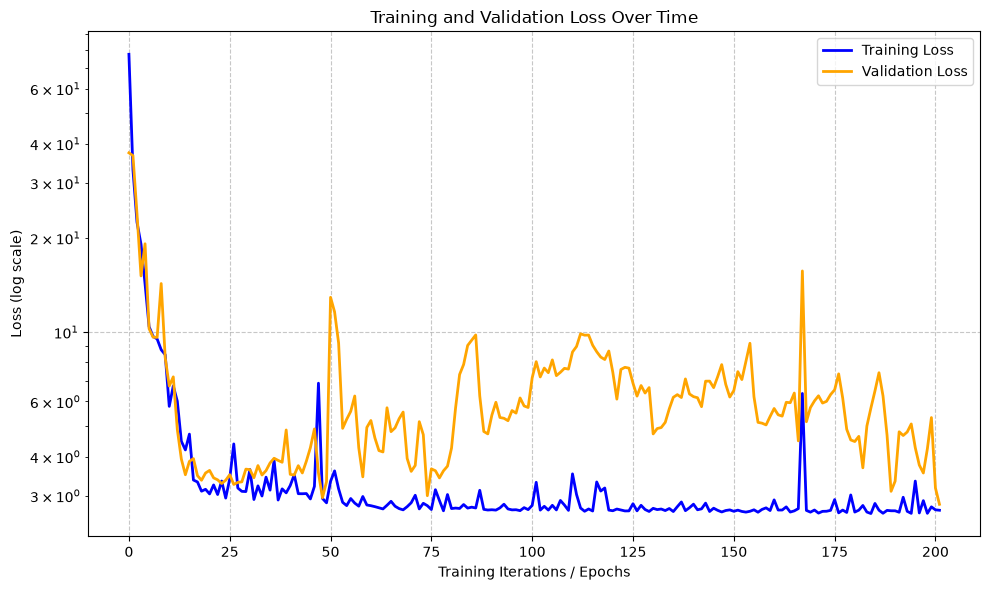

In [28]:
import os
import json
import itertools
from model.gagnn import GAGNN
from model.loss import GAGNNLoss
from torch_geometric.loader import NeighborLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("Computing class weights for the training set...")
y_train_flat = y_trans[train_edge_mask].view(-1).cpu().numpy()
classes = np.unique(y_train_flat)
class_weights_np = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_flat)

class_weights = torch.ones(9, dtype=torch.float)
for i, c in enumerate(classes):
    class_weights[int(c)] = class_weights_np[i]

class_weights = class_weights.to(device)
print(f"Class weights: {class_weights}")

keys = ['max_norm', 'hidden_dim', 'out_dim', 'heads', 'num_layers',
        'beta', 'mlp_hidden_dim', 'nn_t_hidden_dim', 'lr',
        'c1', 'c2', 'c3']
combinations = list(itertools.product(
    max_norm_clipping, hidden_dims, out_dims, heads_list, num_layers_list,
    betas, mlp_hidden_dims, nn_t_hidden_dims, learning_rates,
    c1_list, c2_list, c3_list
))

print(f"Total hyperparameter combinations: {len(combinations)}\n")
os.makedirs(save_to_folder, exist_ok=True)
with open(f"{save_to_folder}/configurations_architecture.txt", "w") as _f:
    _f.write(f"Total configurations tested: {len(combinations)}\n\n")
    _f.write("Hyperparameter grids:\n")
    _f.write(f"max_norm_clipping: {max_norm_clipping}\n")
    _f.write(f"hidden_dims: {hidden_dims}\n")
    _f.write(f"out_dims: {out_dims}\n")
    _f.write(f"heads_list: {heads_list}\n")
    _f.write(f"num_layers_list: {num_layers_list}\n")
    _f.write(f"betas: {betas}\n")
    _f.write(f"mlp_hidden_dims: {mlp_hidden_dims}\n")
    _f.write(f"nn_t_hidden_dims: {nn_t_hidden_dims}\n")
    _f.write(f"learning_rates: {learning_rates}\n")
    _f.write(f"c1_list: {c1_list}\n")
    _f.write(f"c2_list: {c2_list}\n")
    _f.write(f"c3_list: {c3_list}\n")

from sklearn.metrics import f1_score
import numpy as np
best_val_loss = float('inf')
best_params = None

os.makedirs(save_to_folder, exist_ok=True)

for idx, combo in enumerate(combinations):
    params = dict(zip(keys, combo))

    current_num_neighbors = num_neighbors.copy()
    while len(current_num_neighbors) < params['num_layers']:
        current_num_neighbors.append(current_num_neighbors[-1] if current_num_neighbors else 10)
    current_num_neighbors = current_num_neighbors[:params['num_layers']]
    
    if minibatches:
        train_loader = NeighborLoader(
            data, num_neighbors=current_num_neighbors, batch_size=batch_size,
            input_nodes=data.train_node_mask, shuffle=True
        )
        patience_loader = NeighborLoader(
            data, num_neighbors=[-1] * params['num_layers'], batch_size=batch_size,
            input_nodes=data.patience_node_mask, shuffle=False
        )
        val_loader = NeighborLoader(
            data, num_neighbors=[-1] * params['num_layers'], batch_size=batch_size,
            input_nodes=data.val_node_mask, shuffle=False
        )
    else:
        d_dev = data.to(device)
        train_loader = [d_dev]
        patience_loader = [d_dev]
        val_loader = [d_dev]
    print(f"--- Experiment {idx+1}/{len(combinations)} ---")
    print(params)
    
    model = GAGNN(
        node_in_dim=x.shape[1],
        edge_feat_dim=edge_attr.shape[1],
        hidden_dim=params['hidden_dim'],
        out_dim=params['out_dim'],
        heads=params['heads'],
        beta=params['beta'],
        mlp_hidden_dim=params['mlp_hidden_dim'],
        nn_t_hidden_dim=params['nn_t_hidden_dim'],
        minibatches=minibatches, num_classes=9,
        gnn_type=gnn_type,
        num_layers=params['num_layers']
    ).to(device)
    
    criterion = GAGNNLoss(c1=params['c1'], c2=params['c2'], c3=params['c3'], laundry_weight=class_weights, task='multiclass')
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    scaler = torch.amp.GradScaler('cuda', enabled=False)
    
    epochs_no_improve = 0
    best_model_val_loss = float('inf')
    best_epoch_patience_loss = float('inf')
    
    for epoch in range(epochs_model_selection):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        evaluated_train = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
        for batch in train_loader:
            batch = batch.to(device)
            if hasattr(batch, 'e_id'):
                e_id = batch.e_id
                new_mask = ~evaluated_train[e_id]
                evaluated_train[e_id] = True
            else:
                new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
            train_mask = new_mask & batch.edge_train_mask
            if not train_mask.any():
                continue
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                p_node, p_trans, p_group, y_group = model(
                    batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                    y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=train_mask
                )
            
            if p_group.numel() > 0:
                loss, _, _, _ = criterion(
                    p_node, batch.y_node.view(-1, 1),
                    p_trans, batch.y_trans,
                    p_group, y_group,
                    node_mask=batch.node_mask,
                    trans_mask=train_mask
                )
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=params['max_norm'])
                scaler.step(optimizer)
                scaler.update()
                epoch_loss += loss.item()
                n_batches += 1
                
        train_loss = epoch_loss / max(n_batches, 1)
        model.training_losses.append(train_loss)
        
        model.eval()
        patience_loss_epoch = 0.0
        n_patience_batches = 0
        with torch.no_grad():
            for batch in patience_loader:
                batch = batch.to(device)
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    p_node, p_trans, p_group, y_group = model(
                        batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                        y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=batch.edge_patience_mask
                    )
                if p_group.numel() > 0:
                    loss, _, _, _ = criterion(
                        p_node, batch.y_node.view(-1, 1),
                        p_trans, batch.y_trans,
                        p_group, y_group,
                        node_mask=batch.node_mask,
                        trans_mask=batch.edge_patience_mask
                    )
                    patience_loss_epoch += loss.item()
                    n_patience_batches += 1
        patience_loss = patience_loss_epoch / max(n_patience_batches, 1)

        if patience_loss < best_epoch_patience_loss:
            best_epoch_patience_loss = patience_loss
            epochs_no_improve = 0

            val_loss_epoch = 0.0
            n_val_batches = 0
            evaluated_val = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    if hasattr(batch, 'e_id'):
                        e_id = batch.e_id
                        new_mask = ~evaluated_val[e_id]
                        evaluated_val[e_id] = True
                    else:
                        new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
                    val_mask = new_mask & batch.edge_val_mask
                    if not val_mask.any():
                        continue
                    with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                        p_node, p_trans, p_group, y_group = model(
                            batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                            y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=batch.edge_val_mask
                        )
                    if p_group.numel() > 0:
                        loss, _, _, _ = criterion(
                            p_node, batch.y_node.view(-1, 1),
                            p_trans, batch.y_trans,
                            p_group, y_group,
                            node_mask=batch.node_mask,
                            trans_mask=val_mask
                        )
                        val_loss_epoch += loss.item()
                        n_val_batches += 1
                    

            val_loss = val_loss_epoch / max(n_val_batches, 1)
            best_model_val_loss = val_loss
        else:
            epochs_no_improve += 1
        
        model.val_losses.append(patience_loss)

        if epochs_no_improve >= patience_selection:
            print(f"Patience triggered at epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            break
        
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")   
        
            
        print(f"Best Val Loss for this config: {best_model_val_loss:.4f}")
        if best_model_val_loss < best_val_loss:
            best_val_loss = best_model_val_loss
            best_params = params
            model.save(f"{save_to_folder}/gagnn_best_model_selection.pt")
            print(">>> New Best Parameters! Model saved.")
        else:
            print(f"No improvement over best parameters. Current: {best_model_val_loss:.4f} | Best: {best_val_loss:.4f}")

    print("\n=========================================")
    print(f"Overall Best Val Loss: {best_val_loss:.4f}")
    print(f"Best Parameters: {best_params}")
    print("=========================================")
    with open(f"{save_to_folder}/best_params.json", "w") as f:
        json.dump(best_params, f, indent=4)

    print("\nPlotting training history of the best model from model selection...")
    best_selection_model = GAGNN.load_saved(f"{save_to_folder}/gagnn_best_model_selection.pt")
    best_selection_model.plot_training_history()

### Training

In [ ]:
import os
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best hyperparameters for final training...")
with open(f"{save_to_folder}/best_params.json", "r") as f:
    best_params = json.load(f)

print("\nStarting final training on Train dataset with validation...")



# Merge patience into train
data_final = data.clone()
data_final.train_node_mask = data_final.train_node_mask | data_final.patience_node_mask
data_final.edge_train_mask = data_final.edge_train_mask | data_final.edge_patience_mask

# Use val as new patience
data_final.patience_node_mask = data_final.val_node_mask
data_final.edge_patience_mask = data_final.edge_val_mask

if minibatches:
    current_num_neighbors = num_neighbors.copy()
    while len(current_num_neighbors) < best_params['num_layers']:
        current_num_neighbors.append(current_num_neighbors[-1] if current_num_neighbors else 10)
    current_num_neighbors = current_num_neighbors[:best_params['num_layers']]

    final_train_loader = NeighborLoader(
        data_final, num_neighbors=current_num_neighbors, batch_size=batch_size,
        input_nodes=data_final.train_node_mask, shuffle=True
    )
    final_patience_loader = NeighborLoader(
        data_final, num_neighbors=[-1] * best_params['num_layers'], batch_size=batch_size,
        input_nodes=data_final.patience_node_mask, shuffle=False
    )
    
else:
    d_dev = data_final.to(device)
    final_train_loader = [d_dev]
    final_patience_loader = [d_dev]
    

print(f"Batches per epoch (Final Train): {len(final_train_loader)}")

# Re-initialize the model with best parameters
final_model = GAGNN(
    node_in_dim=x.shape[1],
    edge_feat_dim=edge_attr.shape[1],
    hidden_dim=best_params['hidden_dim'],
    out_dim=best_params['out_dim'],
    heads=best_params['heads'],
    beta=best_params['beta'],
    mlp_hidden_dim=best_params['mlp_hidden_dim'],
    nn_t_hidden_dim=best_params['nn_t_hidden_dim'],
    minibatches=minibatches, num_classes=9,
    gnn_type=gnn_type,
    num_layers=best_params['num_layers']
).to(device)

final_criterion = GAGNNLoss(c1=best_params['c1'], c2=best_params['c2'], c3=best_params['c3'], laundry_weight=class_weights, task='multiclass')
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])
scaler = torch.amp.GradScaler('cuda', enabled=False)

os.makedirs(save_to_folder, exist_ok=True)

best_final_patience_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs_train):
    final_model.train()
    epoch_loss = 0.0
    n_batches = 0
    
    evaluated_train = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
    for batch in final_train_loader:
        batch.to(device)
        if hasattr(batch, 'e_id'):
            e_id = batch.e_id
            new_mask = ~evaluated_train[e_id]
            evaluated_train[e_id] = True
        else:
            new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
        train_mask = new_mask & batch.edge_train_mask
        if not train_mask.any():
            continue
        final_optimizer.zero_grad()
        
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            p_node, p_trans, p_group, y_group = final_model(
                batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=train_mask
            )
        
        if p_group.numel() > 0:
            loss, _, _, _ = final_criterion(
                p_node, batch.y_node.view(-1, 1),
                p_trans, batch.y_trans,
                p_group, y_group,
                node_mask=batch.node_mask,
                trans_mask=train_mask
            )
            scaler.scale(loss).backward()
            scaler.unscale_(final_optimizer)
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=best_params['max_norm'])
            scaler.step(final_optimizer)
            scaler.update()
            epoch_loss += loss.item()
            n_batches += 1
            
    train_loss = epoch_loss / max(n_batches, 1)
    final_model.training_losses.append(train_loss)
    
    # Validation step
    final_model.eval()
    patience_loss_epoch = 0.0
    n_patience_batches = 0
    with torch.no_grad():
        for batch in final_patience_loader:
            batch.to(device)
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                p_node, p_trans, p_group, y_group = final_model(
                    batch.x, batch.edge_index, batch.edge_attr, batch.edge_index.size(1),
                    y_node=batch.y_node, y_trans=batch.y_trans, trans_mask=batch.edge_patience_mask
                )
            if p_group.numel() > 0:
                loss, _, _, _ = final_criterion(
                    p_node, batch.y_node.view(-1, 1),
                    p_trans, batch.y_trans,
                    p_group, y_group,
                    node_mask=batch.node_mask,
                    trans_mask=batch.edge_patience_mask
                )
                patience_loss_epoch += loss.item()
                n_patience_batches += 1
    patience_loss = patience_loss_epoch / max(n_patience_batches, 1)
    final_model.val_losses.append(patience_loss)
        
    if (epoch + 1) % print_every == 0:
        print(f"Train Epoch {epoch+1:03d}/{epochs_train} | Train Loss: {train_loss:.4f} | Patience Loss: {patience_loss:.4f}")
        
    if patience_loss < best_final_patience_loss:
        best_final_patience_loss = patience_loss
        epochs_no_improve = 0
        final_model.save(f"{save_to_folder}/model_trained_final.pt")
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience_training:
        print(f"Patience triggered at epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Patience Loss: {patience_loss:.4f}")
        break
        
    # Save model every 10 epochs
    if (epoch + 1) % save_every == 0:
        final_model.save(f"{save_to_folder}/model_trained_{epoch+1}.pt")

print("\nPlotting training history of the final trained model...")
final_model.plot_training_history()



Loading best hyperparameters for final training...

Starting final training on Train dataset with validation...
Batches per epoch (Final Train): 21


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!


Loading best model for final evaluation on Test set...
    EVALUATION REPORT (Transactions / Edges)
  Accuracy  : 0.3763
  Precision : 0.2817
  Recall    : 0.2912
  F1-Score  : 0.2387
  ROC-AUC   : 0.7104
--------------------------------------------------
                precision    recall  f1-score   support

         LEGIT       0.96      0.42      0.58      1922
       FAN-OUT       0.26      0.08      0.12       140
        FAN-IN       0.38      0.72      0.50       137
         CYCLE       0.04      0.14      0.07       109
GATHER-SCATTER       0.53      0.53      0.53       401
SCATTER-GATHER       0.19      0.07      0.10       252
     BIPARTITE       0.03      0.39      0.05        74
         STACK       0.15      0.28      0.20       140
        RANDOM       0.00      0.00      0.00        86

      accuracy                           0.38      3261
     macro avg       0.28      0.29      0.24      3261
  weighted avg       0.68      0.38      0.45      3261



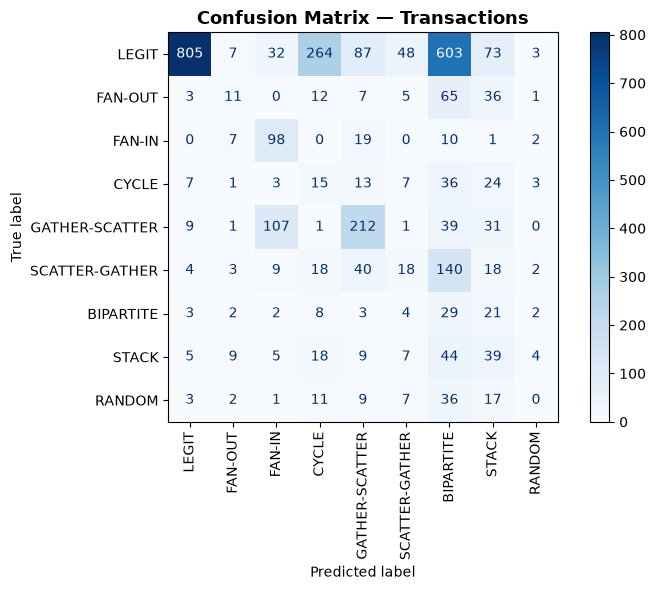

In [ ]:
from utils import Evaluator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best model for final evaluation on Test set...")
eval_model = GAGNN.load_saved(f"{save_to_folder}/model_trained_final.pt").to(device)

with open(f"{save_to_folder}/best_params.json", "r") as f:
    best_params = json.load(f)

eval_criterion = GAGNNLoss(c1=best_params['c1'], c2=best_params['c2'], c3=best_params['c3'], task='multiclass')

if minibatches:
    test_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.test_node_mask, shuffle=False
    )
    Evaluator.evaluation_report(eval_model, test_loader, eval_criterion, device, edge_mask_name='edge_test_mask', task='multiclass')
else:
    Evaluator.evaluation_report(eval_model, [d_dev], eval_criterion, device, edge_mask_name='edge_test_mask', task='multiclass')

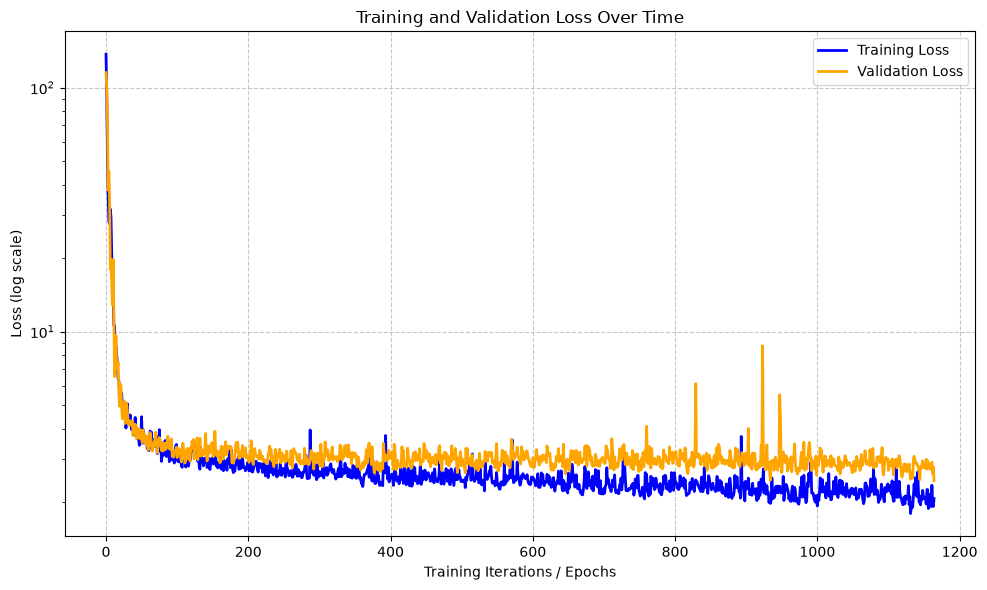

In [ ]:
eval_model.plot_training_history()

## Baseline: Standalone GAT (without GAGNN pipeline)

Ablation study: trains **only the GAT backbone** — no eMRF, no
GroupRepresentationLayer, no multi-task GAGNN loss — as a direct edge-level
Money Laundering classifier.

Edge features are fed **into GNN message passing** (native `edge_dim` support).

The same `data`, `train_node_mask`, `val_node_mask`, and `test_node_mask`
built earlier in this notebook are reused without modification.

In [ ]:
# =============================================================================
# Baseline GAT — Hyperparameter Grid
# =============================================================================
baseline_save_to_folder = 'saved_models_GAT/baseline'

baseline_epochs_train = 6000

baseline_patience_training = 150

### Baseline — Training

In [ ]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score
from model.standalone_gnn import StandaloneGNN, StandaloneGNNLoss
from torch_geometric.loader import NeighborLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best GAGNN hyperparameters to use for baseline...")
with open(f"{save_to_folder}/best_params.json", "r") as f:
    best_baseline_params = json.load(f)
print(best_baseline_params)

print("\nStarting baseline final training...")


data_final = data.clone()
data_final.train_node_mask = data_final.train_node_mask | data_final.patience_node_mask
data_final.edge_train_mask = data_final.edge_train_mask | data_final.edge_patience_mask
data_final.patience_node_mask = data_final.val_node_mask
data_final.edge_patience_mask = data_final.edge_val_mask

if minibatches:
    current_num_neighbors = num_neighbors.copy()
    while len(current_num_neighbors) < best_params['num_layers']:
        current_num_neighbors.append(current_num_neighbors[-1] if current_num_neighbors else 10)
    current_num_neighbors = current_num_neighbors[:best_params['num_layers']]

    final_train_loader = NeighborLoader(
        data_final, num_neighbors=current_num_neighbors, batch_size=batch_size,
        input_nodes=data_final.train_node_mask, shuffle=True
    )
    final_patience_loader = NeighborLoader(
        data_final, num_neighbors=[-1] * best_params['num_layers'], batch_size=batch_size,
        input_nodes=data_final.patience_node_mask, shuffle=False
    )
    
else:
    d_dev = data_final.to(device)
    final_train_loader = [d_dev]
    final_patience_loader = [d_dev]
    

final_model = StandaloneGNN(
    node_in_dim=x.shape[1],
    edge_feat_dim=edge_attr.shape[1],
    hidden_dim=best_baseline_params['hidden_dim'],
    out_dim=best_baseline_params['out_dim'],
    heads=best_baseline_params['heads'],
    num_layers=best_baseline_params['num_layers'],
    gnn_type='gat',
    mlp_hidden_dim=best_baseline_params['mlp_hidden_dim'],
    minibatches=minibatches, num_classes=9,
).to(device)

final_criterion = StandaloneGNNLoss(
    laundry_weight=class_weights, task='multiclass'
)
final_optimizer = torch.optim.Adam(
    final_model.parameters(), lr=best_baseline_params['lr']
)
scaler = torch.amp.GradScaler('cuda', enabled=False)

os.makedirs(baseline_save_to_folder, exist_ok=True)

best_final_patience_loss = float('inf')
epochs_no_improve = 0

for epoch in range(baseline_epochs_train):
    final_model.train()
    epoch_loss = 0.0
    n_batches  = 0

    evaluated_train = torch.zeros(data.num_edges, dtype=torch.bool, device=device)
    for batch in final_train_loader:
        if hasattr(batch, 'e_id'):
            e_id = batch.e_id
            new_mask = ~evaluated_train[e_id]
            evaluated_train[e_id] = True
        else:
            new_mask = torch.ones(batch.num_edges, dtype=torch.bool, device=device)
        train_mask = new_mask & batch.edge_train_mask
        if not train_mask.any():
            continue
        final_optimizer.zero_grad()

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                p_trans = final_model(batch.x, batch.edge_index, batch.edge_attr)
                loss = final_criterion(p_trans, batch.y_trans, trans_mask=train_mask)

        scaler.scale(loss).backward()
        scaler.unscale_(final_optimizer)
        torch.nn.utils.clip_grad_norm_(
            final_model.parameters(), best_baseline_params['max_norm']
        )
        scaler.step(final_optimizer)
        scaler.update()

        epoch_loss += loss.item()
        n_batches  += 1

    final_model.training_losses.append(epoch_loss / max(n_batches, 1))

    # --- Validation ---
    final_model.eval()
    patience_loss_epoch = 0.0
    n_patience_batches = 0
    with torch.no_grad():
        for batch in final_patience_loader:
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                p_trans = final_model(batch.x, batch.edge_index, batch.edge_attr)
            if p_trans.numel() > 0:
                loss = final_criterion(
                    p_trans, batch.y_trans, trans_mask=batch.edge_patience_mask
                )
                patience_loss_epoch += loss.item()
                n_patience_batches += 1
    patience_loss = patience_loss_epoch / max(n_patience_batches, 1)
    final_model.val_losses.append(patience_loss)
    
    if epoch % print_every == 0:
        avg_loss = epoch_loss / max(n_batches, 1)
        print(f"Epoch {epoch + 1:4d} | Loss {avg_loss:.4f} | Patience Loss {patience_loss:.4f}")

    if patience_loss < best_final_patience_loss:
        best_final_patience_loss = patience_loss
        epochs_no_improve = 0
        final_model.save(f"{baseline_save_to_folder}/baseline_model_final.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= baseline_patience_training:
        print(f"Early stopping at epoch {epoch + 1}")
        break

print(f"\nBest baseline patience Loss (final training): {best_final_patience_loss:.4f}")
print("Model saved to baseline_model_final.pt")


Loading best GAGNN hyperparameters to use for baseline...
{'max_norm': 5.0, 'hidden_dim': 128, 'out_dim': 128, 'heads': 5, 'num_layers': 2, 'beta': 0.44, 'mlp_hidden_dim': 128, 'nn_t_hidden_dim': 256, 'lr': 0.0001, 'c1': 0.75, 'c2': 0.75, 'c3': 0.9}

Starting baseline final training...
Epoch    1 | Loss 11.8536 | Val Loss 5.6935
Epoch   21 | Loss 2.2724 | Val Loss 2.2216
Epoch   41 | Loss 2.1126 | Val Loss 2.4149
Epoch   61 | Loss 1.9110 | Val Loss 2.2328
Epoch   81 | Loss 1.7912 | Val Loss 2.2091
Epoch  101 | Loss 1.7981 | Val Loss 2.2850
Epoch  121 | Loss 1.7342 | Val Loss 2.2673
Epoch  141 | Loss 1.4403 | Val Loss 1.9818
Epoch  161 | Loss 1.5100 | Val Loss 2.1182
Epoch  181 | Loss 1.3824 | Val Loss 2.2279
Epoch  201 | Loss 1.4839 | Val Loss 2.4503
Epoch  221 | Loss 1.3333 | Val Loss 1.9874
Epoch  241 | Loss 1.1981 | Val Loss 2.0998
Epoch  261 | Loss 1.3029 | Val Loss 2.0389
Epoch  281 | Loss 1.3246 | Val Loss 2.1227
Epoch  301 | Loss 1.0557 | Val Loss 1.8966
Epoch  321 | Loss 1.094

### Baseline — Evaluation on Test Set


Loading best baseline model for test evaluation...
  BASELINE EVALUATION REPORT (Transactions / Edges)
  Accuracy  : 0.3585
  Precision : 0.2628
  Recall    : 0.2910
  F1-Score  : 0.2296
  ROC-AUC   : 0.7003
--------------------------------------------------
                precision    recall  f1-score   support

         LEGIT       0.93      0.38      0.54      1922
       FAN-OUT       0.09      0.08      0.08       140
        FAN-IN       0.43      0.64      0.51       137
         CYCLE       0.07      0.17      0.09       109
GATHER-SCATTER       0.34      0.61      0.44       401
SCATTER-GATHER       0.30      0.07      0.12       252
     BIPARTITE       0.05      0.38      0.08        74
         STACK       0.13      0.16      0.15       140
        RANDOM       0.03      0.13      0.05        86

      accuracy                           0.36      3261
     macro avg       0.26      0.29      0.23      3261
  weighted avg       0.65      0.36      0.42      3261



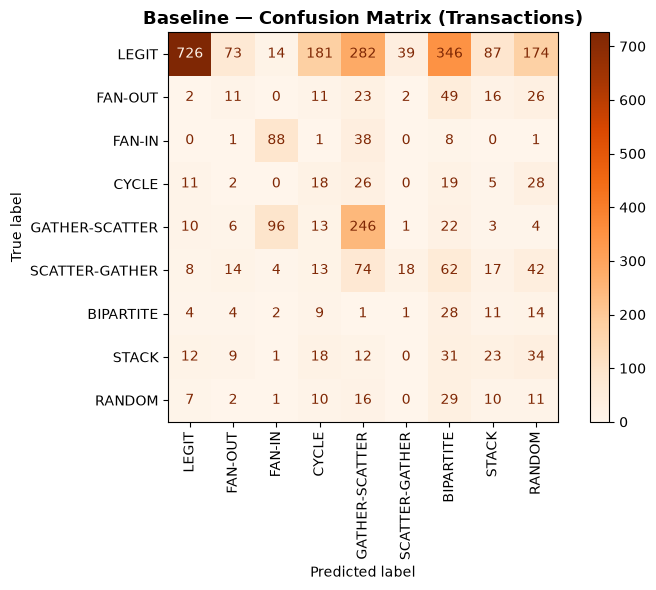

In [ ]:
from model.standalone_gnn import StandaloneGNN
from utils import Evaluator
from torch_geometric.loader import NeighborLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading best baseline model for test evaluation...")
baseline_eval_model = StandaloneGNN.load_saved(
    f"{baseline_save_to_folder}/baseline_model_final.pt"
).to(device)

if minibatches:
    baseline_test_loader = NeighborLoader(
        data, num_neighbors=[-1, -1], batch_size=batch_size,
        input_nodes=data.test_node_mask, shuffle=False
    )
    Evaluator.baseline_evaluation_report(
        baseline_eval_model, baseline_test_loader, device,
        edge_mask_name='edge_test_mask', task='multiclass'
    )
else:
    Evaluator.baseline_evaluation_report(
        baseline_eval_model, [d_dev], device,
        edge_mask_name='edge_test_mask', task='multiclass'
    )

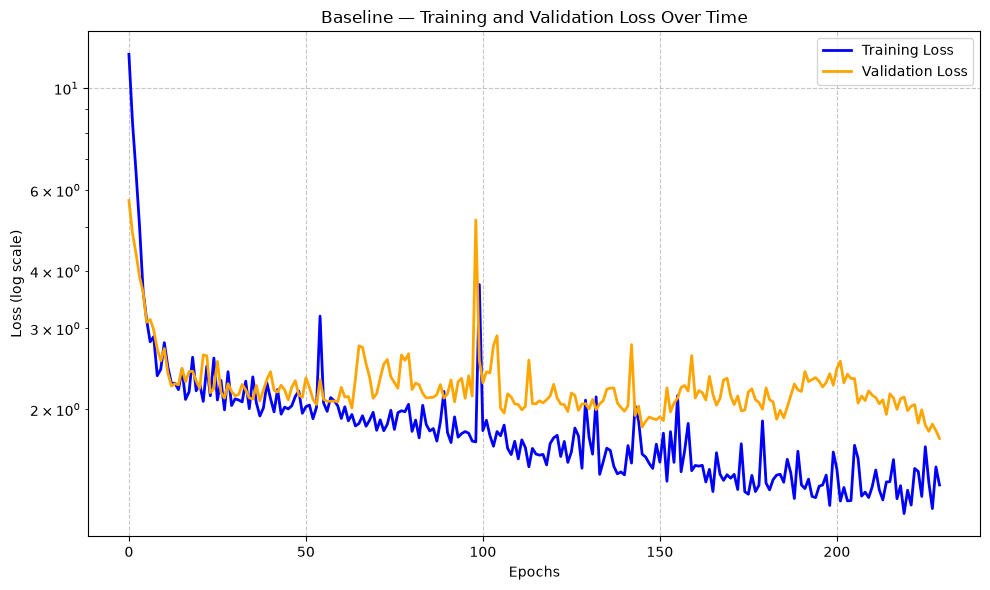

In [ ]:
baseline_eval_model.plot_training_history()